# Term Deposit Subscription Prediction
**European Banking | Customer Intention Classification | Telemarketing Optimisation**

---

## Business Context

A European banking institution runs direct marketing campaigns via phone calls to
promote term deposit subscriptions. The current approach contacts customers
indiscriminately, resulting in low conversion rates, wasted agent resources, and
a poor customer experience.

**Goals:**
1. Predict whether a customer will subscribe to a term deposit (`y`)
2. Determine which features most strongly drive subscription decisions

**Success Metric:** 81%+ accuracy via 5-fold cross-validation (average score)
**Key Operational Metric:** Minority-class recall — catching actual subscribers

## Solution Design: Two-Layer Pipeline

Features fall into two groups separated by a temporal boundary:

| Layer | Features Available | Purpose |
|-------|--------------------|---------|
| **Model 1 : Pre-call** | Demographics + financial history | Predict who to call *before* any contact |
| **Model 2 : Post-call** | All features (incl. call data) | Predict who to *continue* calling after contact |

---
## Import Dependencies

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import random
import duckdb

from src.cluster_model import cluster_subscribers
from src.two_layer_model import (
    load_data, get_feature_sets, explore_data,
    split_data, data_cleaning, encode_data,
    select_model, compare_ensembles, tune_hyperparameters,
    feature_importance, evaluate_model
)

SEED = random.randint(1000, 9999)
print(f"Seed: {SEED}")

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "term-deposit-marketing-2020.csv"

Seed: 4355


---
## 1. Data Loading

In [2]:
term_deposit_df = load_data(DATA_PATH)
print(f"Shape: {term_deposit_df.shape[0]:,} rows x {term_deposit_df.shape[1]} columns")
term_deposit_df.head()

Shape: 40,000 rows x 14 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


---
## 2. Feature Groups

Features are split into pre-call and post-call groups based on when they become available.
`duration` is in the post-call group — it only exists after a call ends and must not
be used in Model 1 (data leakage).

In [3]:
pre_call_cols, post_call_cols = get_feature_sets(term_deposit_df)
all_cols = pre_call_cols + post_call_cols
print(f"Model 1 — Pre-call  : {pre_call_cols}")
print(f"Model 2 adds        : {post_call_cols}")

Model 1 — Pre-call  : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
Model 2 adds        : ['contact', 'day', 'month', 'duration', 'campaign']


---
## 3. Exploratory Data Analysis

EDA covers target distribution, feature distributions by class, numeric histograms,
correlation structure, and identification of structural missing values (`"unknown"`).

       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
39995   53    technician   married   tertiary      no      395      no   no   
39996   30    management    single   tertiary      no     3340      no   no   
39997   54         admin  divorced  secondary      no      200      no   no   
39998   34    management   married   tertiary      no     1047      no   no   
39999   38    technician   married  secondary      no     1442     yes   no   

        contact  day month  duration  campaign    y  
0       unknown    5   may       261         1   no  
1       unknown    5  

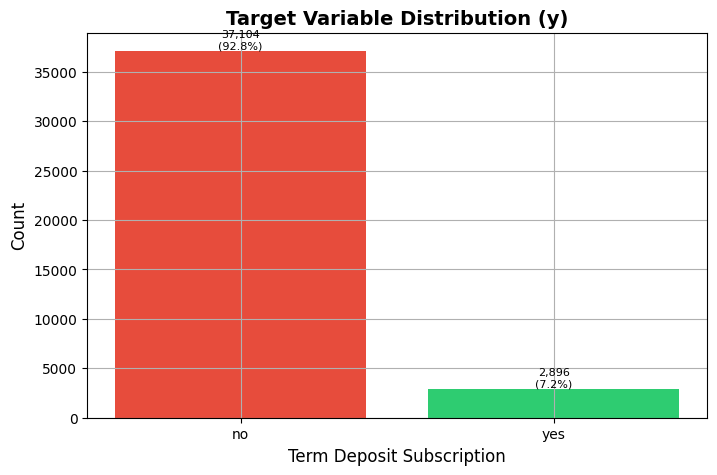


--- job ---
job
blue-collar      9383
management       8166
technician       6852
admin            4483
services         3910
retired          1437
self-employed    1414
entrepreneur     1405
unemployed       1104
housemaid        1087
student           524
unknown           235
Name: count, dtype: int64


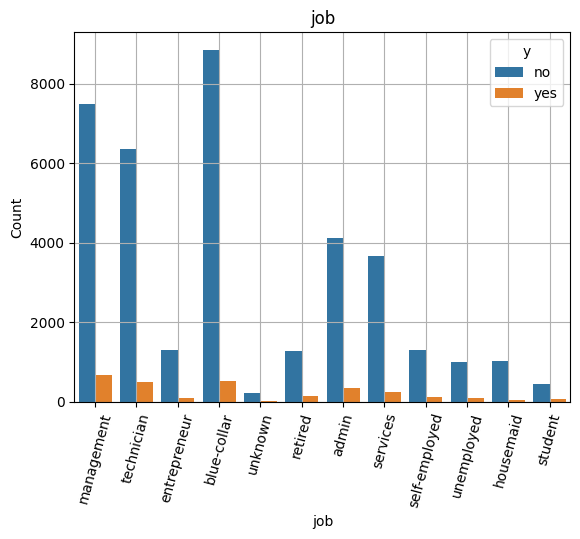


--- marital ---
marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64


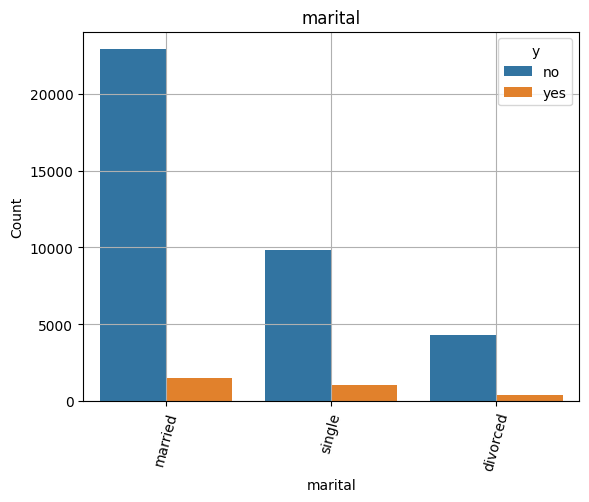


--- education ---
education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64


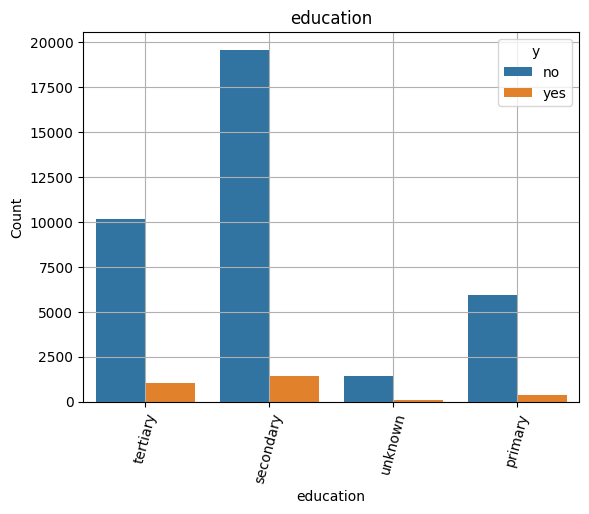


--- default ---
default
no     39191
yes      809
Name: count, dtype: int64


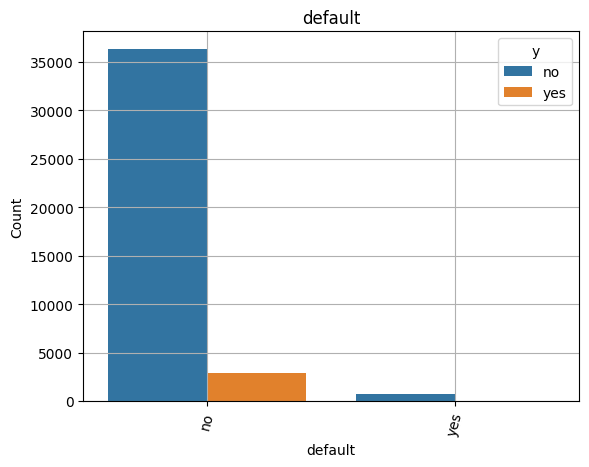


--- housing ---
housing
yes    24031
no     15969
Name: count, dtype: int64


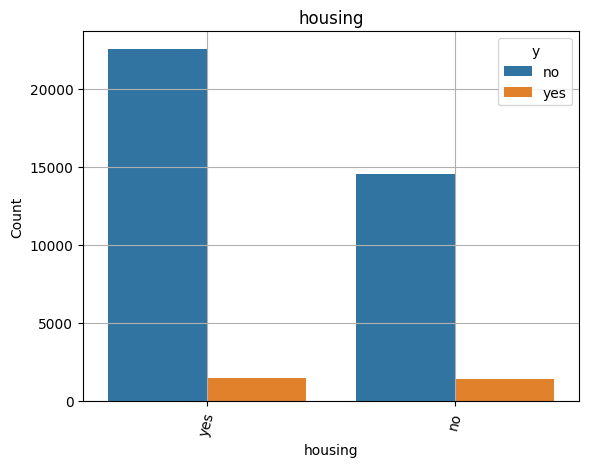


--- loan ---
loan
no     33070
yes     6930
Name: count, dtype: int64


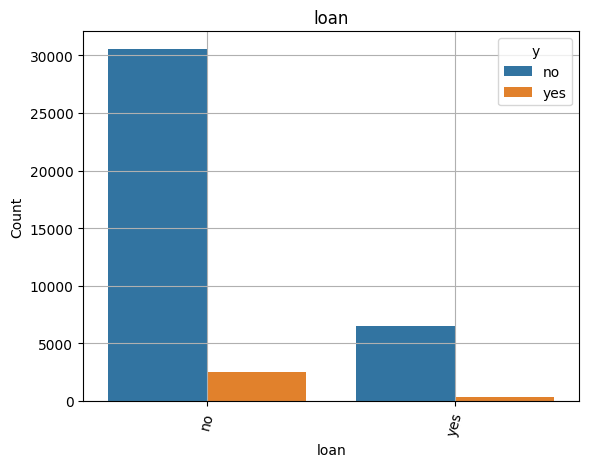


--- contact ---
contact
cellular     24914
unknown      12765
telephone     2321
Name: count, dtype: int64


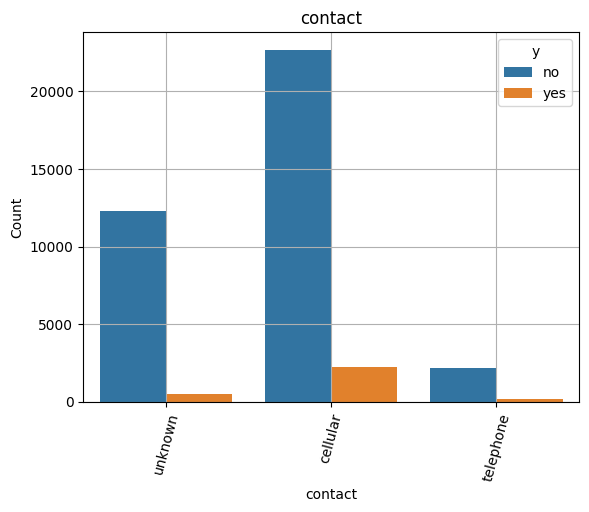


--- month ---
month
may    13532
jul     6380
aug     5215
jun     4734
nov     3598
apr     2718
feb     2296
jan     1176
mar      258
oct       80
dec       13
Name: count, dtype: int64


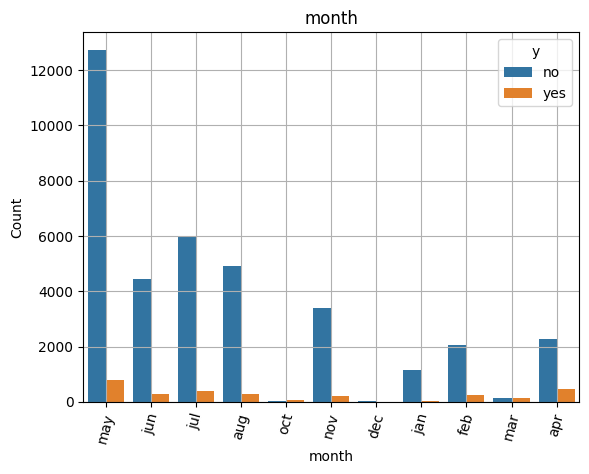


Unknown value counts:
  job: 235 (0.6%)
  education: 1,531 (3.8%)
  contact: 12,765 (31.9%)

Pairwise overlap:
  job & education: 104
  job & contact: 110
  education & contact: 666
  all three: 54

Rows lost if any unknown dropped: 13,705 (34.3%)


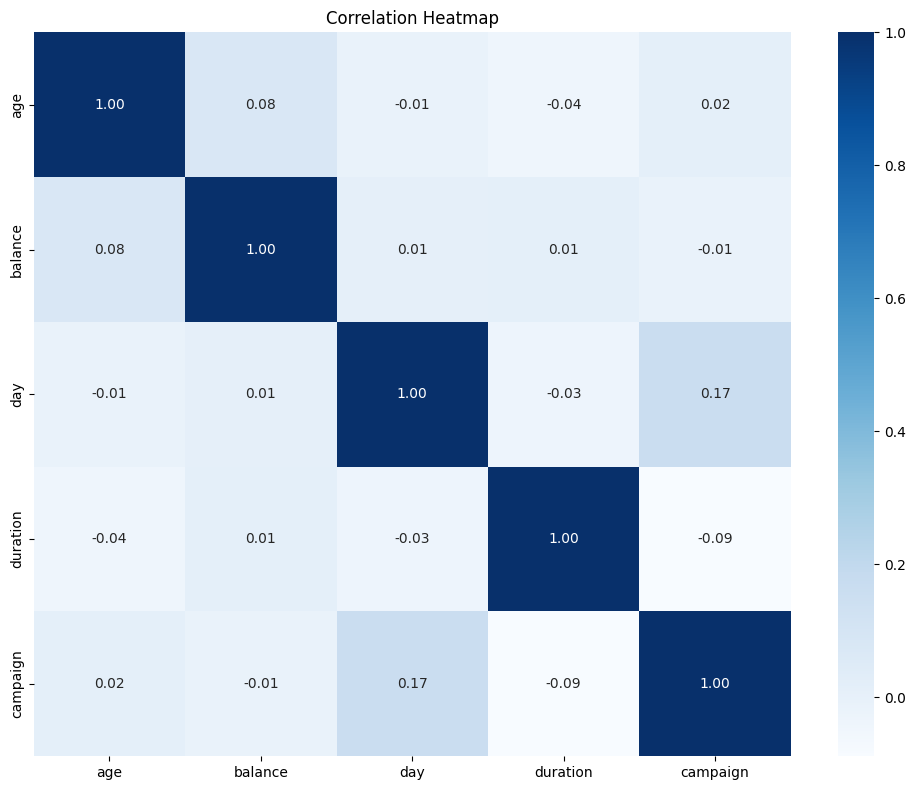

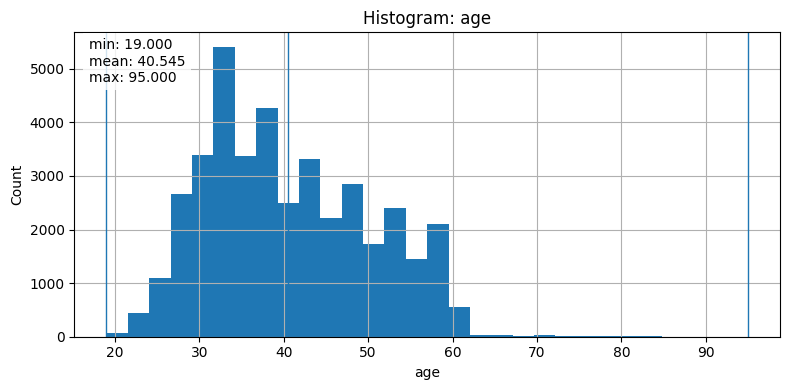

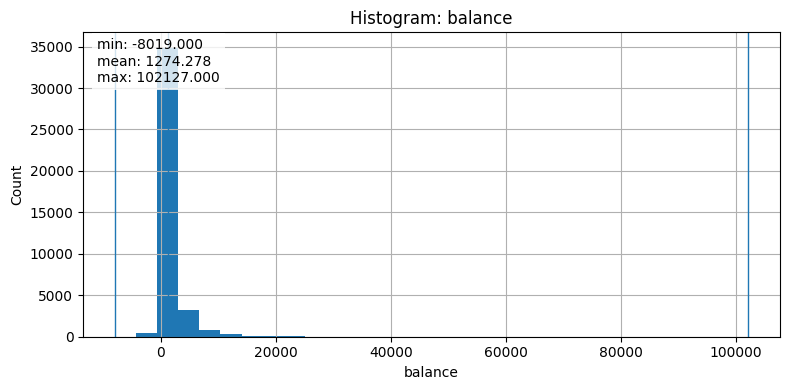

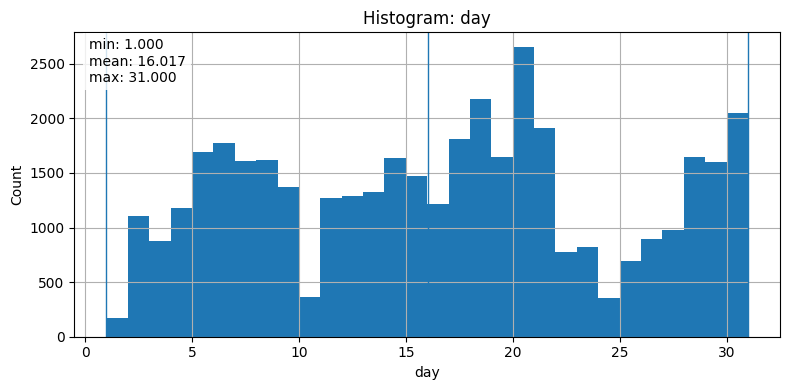

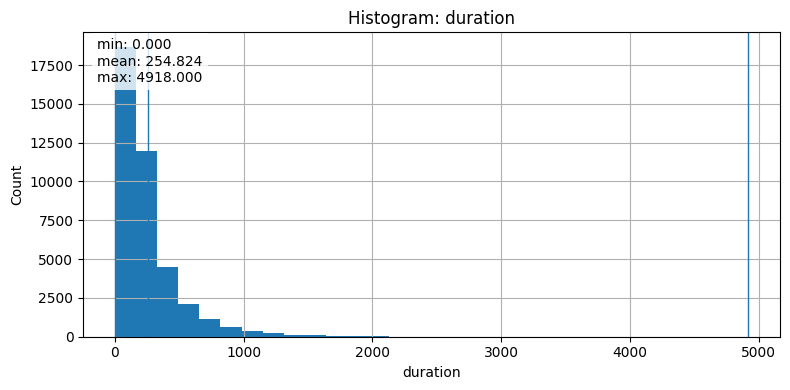

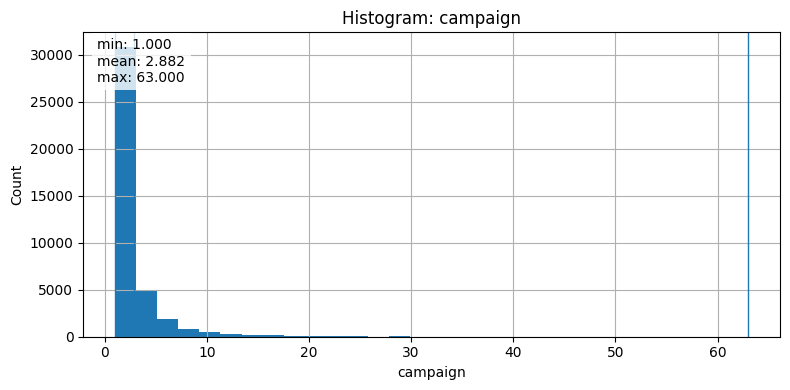

campaign: min=1, max=63 (# contacts this campaign)


In [4]:
numeric_df, categorical_df = explore_data(term_deposit_df)

### Key Findings

#### Class Imbalance

| Class | Count | Share |
|-------|-------|-------|
| No (did not subscribe) | 37104 | 92.8% |
| Yes (subscribed) | 2896 | 7.2% |

The dataset is highly imbalanced. A majority-class classifier achieves 93% accuracy
while being useless to the business. This drives two decisions:
- **Metric:** Optimise for minority-class recall alongside the 81% accuracy target
- **Model config:** `class_weight='balanced'` to penalise missed subscribers

---

#### Numeric Variables

- **`age`:** Range 18–95, mean ~41. No anomalies.
- **`balance`:** Average yearly balance in euros. Can be negative (overdrafts).
  Range −8,019 to 102,127; highly right-skewed with significant outliers.
- **`day`:** Day of month of last contact (1–31). Not a duration. Most calls have been made around 20th
- **`duration`:** Last call duration in seconds. Highly predictive but only known
  *after* the call ends; excluded from Model 1 to prevent data leakage.
- **`campaign`:** Number of contacts made this campaign. Most customers are contacted
  1–3 times; the distribution has a heavy right tail. Maximum value is 63 which seems an outlier.

---

#### Categorical Variables

- **`job`:** Management, blue-collar, and technician are the three most common categories.
- **`marital`:** Married customers are the majority.
- **`education`:** Secondary education is the most frequent level.
- **`default`:** Very few customers have credit in default — a rare event in the dataset.
- **`housing`:** Roughly evenly split between customers with and without a housing loan.
- **`loan`:** Most customers do not hold a personal loan.
- **`contact`:** The majority of contacts were made via cellular. A substantial portion
  of records have an unknown contact type (see table below).
- **`month`:** May has the highest contact volume by a large margin. No calls were made
  in September, suggesting campaign scheduling constraints.

---

#### Structural Missing Values ("unknown")

Pandas reports zero nulls but it is assumed that the missingness is encoded as the string `"unknown"`:

| Column | Count | % of Dataset |
|--------|-------|-------------|
| `contact` | 12,765 | 31.9% |
| `education` | 1,531 | 3.8% |
| `job` | 235 | 0.6% |

**Overlap analysis** — rows where multiple columns are unknown simultaneously:

| Pair | Rows |
|------|------|
| `contact` & `education` | 666 |
| `contact` & `job` | 110 |
| `education` & `job` | 104 |
| All three | 54 |
| Any one (union) | 13,705 (34.3%) |

**Why rows were not dropped:**
Dropping any row containing "unknown" would remove 34.3% of the dataset, nearly all of it
driven by `contact` alone. Given the existing class imbalance, discarding that volume
would significantly reduce minority-class representation in training.

**Design decision — hybrid imputation strategy:**
- **`contact`** → "unknown" retained as a valid category. At 31.9%, this is not random
  missingness but a distinct cohort (customers reached via an unlogged channel). LabelEncoder assigns
  it its own integer; LightGBM can learn from it.
- **`education` and `job`** → mode-imputed. Sparse unknowns (3.8% and 0.6%) with no
  evidence they form a meaningful segment. Mode imputation is simple and introduces
  negligible bias at this volume.

---

#### Outliers

IQR-based clipping `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]` is applied to all numeric features.
Bounds are computed on training data only to prevent leakage.

---
## 4. Preprocessing Pipeline

All transformations are **fitted on training data only**; no leakage at any stage.

| Step | Method | Rationale |
|------|--------|-----------|
| Train / Val / Test split | Stratified 80 / 10 / 10 | Preserves the 93/7 class ratio across all sets |
| `contact` "unknown" | Kept as valid category | 31.9% — informative cohort, not random missingness |
| `education`, `job` "unknown" | Mode imputation | Sparse unknowns; mode fitted on train only |
| Outlier handling | IQR clipping | Reduces outlier influence without removing rows |
| Categorical encoding | `LabelEncoder` | Converts string categories to integers; compatible with all sklearn estimators |
| Numeric scaling | `StandardScaler` | Features span mixed distributions (`balance`, `duration`, `campaign` are skewed; `age` near-normal; `day` uniform). After IQR clipping, extreme outliers are removed; StandardScaler centres and scales each feature to zero mean and unit variance without distortion |
| Target encoding | `LabelEncoder` | `no` → 0, `yes` → 1 |

### Step 4.1 — Train / Validation / Test Split

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    term_deposit_df, target="y", seed=SEED
)

Train: 32000 | Val: 4000 | Test: 4000


### Step 4.2 — Data Cleaning

Outlier clipping (IQR) fitted on train, applied to val.
Mode imputation for `education` and `job` only; `contact` "unknown" kept as-is.

In [6]:
X_train_cleaned, X_val_cleaned, cat_mode, num_bounds, cat_cols, num_cols = data_cleaning(
    X_train, X_val, categorical_df, numeric_df
)
print("Mode values used for imputation:", cat_mode)

{'job': 'blue-collar', 'marital': 'married', 'education': 'secondary', 'default': 'no', 'housing': 'yes', 'loan': 'no', 'month': 'may'} {'age': (np.float64(10.5), np.float64(70.5)), 'balance': (np.float64(-1844.5), np.float64(3223.5)), 'day': (np.float64(-11.5), np.float64(40.5)), 'duration': (np.float64(-223.5), np.float64(636.5)), 'campaign': (np.float64(-2.0), np.float64(6.0))}
Mode values used for imputation: {'job': 'blue-collar', 'marital': 'married', 'education': 'secondary', 'default': 'no', 'housing': 'yes', 'loan': 'no', 'month': 'may'}


---
## 5. Model Selection

**LazyPredict** benchmarks 30+ classifiers in a single pass, ranked by minority-class
recall on the validation set.

**Selected: LightGBM (`LGBMClassifier`)**

| Criterion | LightGBM |
|-----------|----------|
| Minority-class recall | Consistently top-ranked |
| Class imbalance | Native `class_weight='balanced'` support |
| Interpretability | Feature importance for client-facing insights |
| Speed | Practical for repeated tuning and production retraining |

---
## 6. Hyperparameter Tuning

**Hyperopt** with TPE (Tree-structured Parzen Estimator) performs Bayesian optimisation.
Objective: maximise average minority-class recall across 5-fold cross-validation.

| Parameter | Range | Purpose |
|-----------|-------|---------|
| `n_estimators` | 50–500 | Boosting iterations |
| `max_depth` | 2–8 | Tree depth, controls overfitting |
| `learning_rate` | 0.05–0.2 | Step size shrinkage |
| `num_leaves` | 5–31 | Tree complexity |
| `min_child_samples` | 10–30 | Leaf regularisation |
| `subsample` | 0.7–0.9 | Row sampling |
| `colsample_bytree` | 0.7–0.9 | Feature sampling |

TPE converges in ~50 evaluations by learning from prior trials, where grid search
across this space would require ~1,000+.

---
## 7. Model 1 — Pre-Call Targeting
*Feature set: demographics + financial history only (no call data)*

### Step 7.1 — Encode Features (Model 1)

In [7]:
pre_cat_cols = [c for c in pre_call_cols if c in cat_cols]
pre_num_cols = [c for c in pre_call_cols if c in num_cols]

X_tr_m1, X_va_m1, y_tr_enc, y_va_enc, le1, sc1, le_y1 = encode_data(
    X_train_cleaned[pre_call_cols], X_val_cleaned[pre_call_cols],
    y_train, y_val, pre_cat_cols, pre_num_cols
)
print(f"Model 1 training shape : {X_tr_m1.shape}")
print(f"Features               : {X_tr_m1.columns.tolist()}")

Model 1 training shape : (32000, 8)
Features               : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']


### Step 7.2 — Model Selection (Model 1)

In [8]:
models_df1, _ = select_model(X_tr_m1, X_va_m1, y_tr_enc, y_va_enc)
print(models_df1)

  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2317, number of negative: 29683
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 338
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.072406 -> initscore=-2.550301
[LightGBM] [Info] Start training from score -2.550301

Best model for minority recall: NearestCentroid
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
NearestCentroid                    0.58               0.55     0.55      0.68   
ExtraTreeClassifier                0.89               0.54     0.54      0.88   
DecisionTreeClassifier             0.87               0.53     0.53     

### Step 7.3 — Ensemble Comparison (Model 1)

Compares tree-based, distance-based, and ensemble strategies via 5-fold CV minority recall.
The best-performing architecture is then carried forward to hyperparameter tuning.

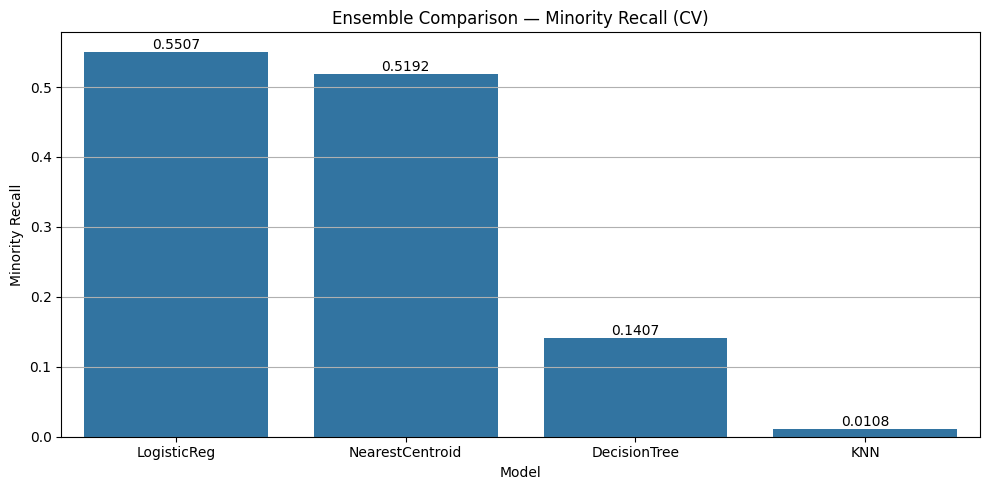

             Model  Minority_Recall
0      LogisticReg             0.55
1  NearestCentroid             0.52
2     DecisionTree             0.14
3              KNN             0.01


In [9]:
fitted_models1, ensemble_df1 = compare_ensembles(X_tr_m1, y_tr_enc, SEED)
print(ensemble_df1)

### Step 7.4 — Hyperparameter Tuning (Model 1)

In [ ]:
model1, params1, score1 = tune_hyperparameters(X_tr_m1, y_tr_enc, X_va_m1, y_va_enc, SEED)

 80%|████████  | 8/10 [04:12<01:16, 38.09s/trial, best loss: -0.5541185900971459]

### Step 7.5 — Feature Importance (Model 1)

In [ ]:
feat1 = feature_importance(X_tr_m1, model1)
print(feat1)

### Step 7.6 — Evaluation on Test Set (Model 1)

In [ ]:
report1, cm1 = evaluate_model(
    model1, X_test[pre_call_cols].copy(), y_test,
    le1, sc1, le_y1,
    pre_cat_cols, pre_num_cols, cat_mode, num_bounds, pre_call_cols, "Model1"
)
print(report1)

---
## 8. Model 2 — Post-Call Follow-Up
*Feature set: all features including call data (`duration`, `contact`, `month`, `day`, `campaign`)*

### Step 8.1 — Encode Features (Model 2)

In [ ]:
all_cat_cols = [c for c in all_cols if c in cat_cols]
all_num_cols = [c for c in all_cols if c in num_cols]

X_tr_m2, X_va_m2, y_tr_enc2, y_va_enc2, le2, sc2, le_y2 = encode_data(
    X_train_cleaned[all_cols], X_val_cleaned[all_cols],
    y_train, y_val, all_cat_cols, all_num_cols
)
print(f"Model 2 training shape : {X_tr_m2.shape}")
print(f"Features               : {X_tr_m2.columns.tolist()}")

### Step 8.2 — Model Selection (Model 2)

In [ ]:
models_df2, _ = select_model(X_tr_m2, X_va_m2, y_tr_enc2, y_va_enc2)
print(models_df2)

### Step 8.3 — Ensemble Comparison (Model 2)

In [ ]:
fitted_models2, ensemble_df2 = compare_ensembles(X_tr_m2, y_tr_enc2, SEED)
print(ensemble_df2)

### Step 8.4 — Hyperparameter Tuning (Model 2)

In [ ]:
model2, params2, score2 = tune_hyperparameters(X_tr_m2, y_tr_enc2, X_va_m2, y_va_enc2, SEED)

### Step 8.5 — Feature Importance (Model 2)

In [ ]:
feat2 = feature_importance(X_tr_m2, model2)
print(feat2)

### Step 8.6 — Evaluation on Test Set (Model 2)

In [ ]:
report2, cm2 = evaluate_model(
    model2, X_test[all_cols].copy(), y_test,
    le2, sc2, le_y2,
    all_cat_cols, all_num_cols, cat_mode, num_bounds, all_cols, "Model2"
)
print(report2)

---
## 9. Results Summary

In [ ]:
print("Model 1: Who to Call (Pre-Call Targeting)")
print("  Business question : Which customers are worth contacting?")
print(f"  CV Minority Recall : {score1:.4f}")
print("  Feature Importance:")
print(feat1.to_string(index=False))

print("\nModel 2: Who Will Subscribe (Post-Call Follow-Up)")
print("  Business question : Of those contacted, who is likely to subscribe?")
print(f"  CV Minority Recall : {score2:.4f}")
print("  Feature Importance:")
print(feat2.to_string(index=False))

### Business Impact

In [ ]:
CAMPAIGN_SIZE = 40_000

# Model 1 confusion matrix: rows = actual, cols = predicted
# [TN, FP]   --> actual Do Not Call
# [FN, TP]   --> actual Call (subscriber)
tn1, fp1, fn1, tp1 = cm1.ravel()
total1 = tn1 + fp1 + fn1 + tp1

predicted_no_call   = tn1 + fn1          # model says "Do Not Call"
predicted_call      = tp1 + fp1          # model says "Call"
pct_saved           = predicted_no_call / total1

calls_saved         = int(pct_saved * CAMPAIGN_SIZE)
useless_calls_test  = fp1                # called but won't subscribe
missed_subs_test    = fn1               # missed subscribers
correct_calls_test  = tp1              # correctly targeted

avg_duration_sec     = X_train['duration'].mean()           # avg call duration from train only
avg_duration_min     = avg_duration_sec / 60
hours_saved_test     = predicted_no_call * avg_duration_sec / 3600
hours_saved_campaign = calls_saved * avg_duration_sec / 3600

print(f"Business Impact: Model 1 (Pre-Call Targeting)")
print(f"  Test set size               : {total1:,}")
print(f"  Predicted 'Do Not Call'     : {predicted_no_call:,}  ({100 * pct_saved:.1f}% of test set)")
print(f"  Predicted 'Call'            : {predicted_call:,}")
print()
print(f"  Scaled to {CAMPAIGN_SIZE:,} campaign contacts:")
print(f"    Calls avoided (saved manpower) by the company is : {calls_saved:,}")
print()
print(f"  Average call duration       : {avg_duration_sec:.0f}s  ({avg_duration_min:.1f} min)")
print(f"  Hours saved (test)    : {hours_saved_test:.1f} hours")
print(f"  Hours saved ({CAMPAIGN_SIZE:,})  : {hours_saved_campaign:.0f} hours  ({hours_saved_campaign/8:.0f} working days)")
print()
print(f"  Within the {predicted_call:,} calls made (test set):")
print(f"    Correctly targeted        : {correct_calls_test:,}  (likely subscribers)")
print(f"    Useless calls             : {useless_calls_test:,}  (won't subscribe)")
print(f"    Missed subscribers        : {missed_subs_test:,}  (false negatives)")

---
## 10. Subscriber Segmentation — KMeans Clustering

In [ ]:
subscribers = duckdb.sql("""
    SELECT *
    FROM term_deposit_df
    WHERE y = 'yes'
""").df()

print(f"Subscribers: {len(subscribers):,}")
cluster_subscribers(subscribers)

### Plot 1 — Scatter Plot: age vs balance (Standardised)

**What it shows:** The raw distribution of the 2,896 subscribers across the two most financially descriptive numerical features before any clustering is applied.

**Conclusion:** Subscribers are spread across all age groups (18–70 after IQR clipping) and a wide balance range. The scatter is not tightly grouped, confirming that subscribers are a heterogeneous group — there is no single "typical" subscriber profile on these two dimensions alone. This motivates clustering across all 5 numerical features to find hidden structure.

---

### Plot 2 — KMeans k=2 to k=6 (5-panel)

**What it shows:** How the age-balance space is partitioned as the number of clusters increases from 2 to 6. Yellow markers are centroids.

**Conclusion:** At low k (2–3), clusters separate subscribers by balance level — a financially wealthier group vs a lower-balance group. As k increases, age begins to contribute more to the partitioning. Beyond k=3 the clusters fragment without producing meaningfully distinct groups, suggesting diminishing returns. The silhouette score and elbow method (below) guide the optimal choice.

---

### Plot 3 — Silhouette Scores (2×2 grid, k=2 to k=5)

**What it shows:** Each subplot shows the cluster assignments for a given k alongside its silhouette score. The silhouette score ranges from −1 to 1: higher values mean clusters are dense and well-separated.

**Conclusion:** The silhouette score peaks at **k=2**, indicating that two clusters best capture the structure in the subscriber data across all 5 features. This is consistent with the "most parsimonious clustering" comment in the code — splitting subscribers into two behavioural segments is statistically justified and operationally interpretable.

---

### Plot 4 — Cluster Describe (k=2)

**What it shows:** Descriptive statistics (`mean`, `std`, `min`, `max`) for each of the two clusters, computed on the standardised features.

**Conclusion — Two subscriber segments emerge:**

| | Cluster 0 | Cluster 1 |
|---|---|---|
| `age` | Lower (younger) | Higher (older) |
| `balance` | Lower | Higher |
| `duration` | Longer calls | Shorter calls |
| `campaign` | More contacts needed | Fewer contacts needed |

- **Cluster 0 — Younger, lower-balance subscribers:** These customers required longer calls and more campaign contacts before committing. They may be first-time savers or less financially established. Higher persuasion cost per conversion.
- **Cluster 1 — Older, higher-balance subscribers:** These customers converted with shorter calls and fewer contacts. Likely experienced savers with existing financial products. Lower persuasion cost and higher lifetime value.

---

### Plot 5 — Correlated Feature Pairs (3-panel)

**age vs balance (corr: 0.08)**
Clusters separate primarily along the balance axis rather than age. Older customers tend to have slightly higher balances (consistent with the 0.08 correlation), but the overlap is large. The wealthier cluster spans all ages, suggesting that financial position — not age alone — drives subscription behaviour.

**age vs duration (corr: −0.04)**
The negative correlation confirms that younger subscribers tend to have longer call durations. Younger customers take longer to be convinced, which is an important operational insight — agents should expect and budget for longer calls when targeting younger segments.

**day vs campaign (corr: 0.17)**
Contacts later in the month correlate weakly with more campaign attempts. The clustering shows that high-quality subscribers (Cluster 1) tend to be reached with fewer calls and earlier in the month, while Cluster 0 subscribers required more persistent follow-up.

---

### Plot 6 — Elbow Method (WCSS)

**What it shows:** Within-Cluster Sum of Squares (WCSS) for k=1 to 6. The "elbow" — where the rate of decrease sharply slows — indicates the optimal number of clusters.

**Conclusion:** The elbow occurs at **k=2**, consistent with the silhouette score finding. Beyond k=2, adding more clusters reduces WCSS marginally but at the cost of interpretability. Two clusters is the statistically and operationally optimal segmentation for this subscriber population.

---

### Overall Clustering Conclusion

KMeans clustering on the 2,896 confirmed subscribers reveals **two distinct behavioural segments**:

| Segment | Profile | Campaign Strategy |
|---|---|---|
| **Cluster 0** — High-effort converters | Younger, lower balance, longer calls, more contacts | Allow more agent time; use patience-based scripts |
| **Cluster 1** — Low-effort converters | Older, higher balance, shorter calls, fewer contacts | Prioritise in targeting; high ROI per call |

These segments are not visible from the full dataset (which is dominated by non-subscribers) and only emerge after DuckDB filtering to `y = 'yes'`. The bank should develop **differentiated contact strategies** for each segment to maximise conversion efficiency.